<a href="https://colab.research.google.com/github/ltd03112007-lab/BTVN/blob/main/2_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.1 MB/s eta 0:00:00


In [ ]:
pip install numpy

In [12]:
import skfuzzy as fuzz
import numpy as np
import skfuzzy.control as ctrl

store_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'store_rating')
sales_volume = ctrl.Antecedent(np.arange(0, 101, 1), 'sales_volume')
profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin')
seasonal_event = ctrl.Antecedent(np.arange(0, 101, 1), 'seasonal_event')
competitive_discount= ctrl.Antecedent(np.arange(0,101,1),'competitive_discount')
percentage_discount=ctrl.Consequent(np.arange(0,70.1,0.1),'percentage_discount')


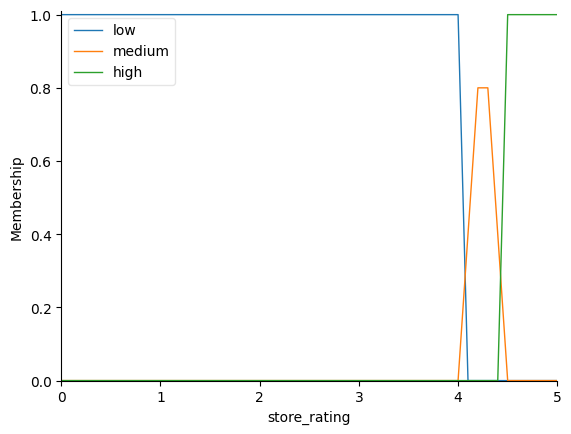

In [13]:
store_rating['low'] = fuzz.trapmf(store_rating.universe, [0, 0, 4,4])
store_rating['medium'] = fuzz.trimf(store_rating.universe, [4, 4.25,4.5 ])
store_rating['high'] = fuzz.trapmf(store_rating.universe, [4.5,4.5,5, 5])
store_rating.view()

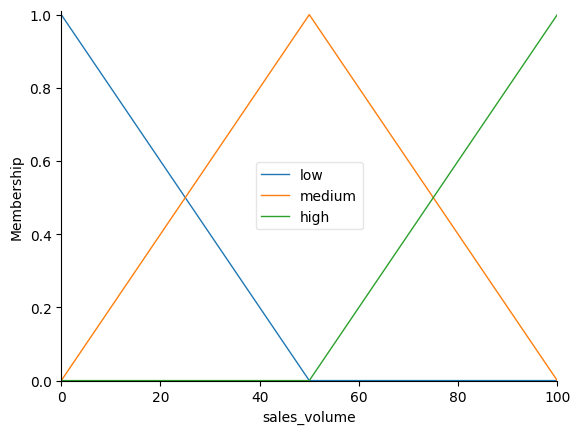

In [14]:
sales_volume['low'] = fuzz.trimf(sales_volume.universe, [0, 0, 50])
sales_volume['medium'] = fuzz.trimf(sales_volume.universe, [0, 50, 100])
sales_volume['high'] = fuzz.trimf(sales_volume.universe, [50, 100, 100])
sales_volume.view()

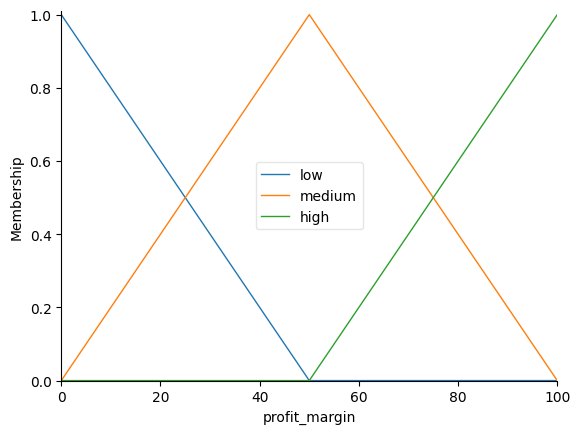

In [17]:
profit_margin['low'] = fuzz.trimf(profit_margin.universe, [0, 0, 50])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [0, 50, 100])
profit_margin['high'] = fuzz.trimf(profit_margin.universe, [50, 100, 100])
profit_margin.view()

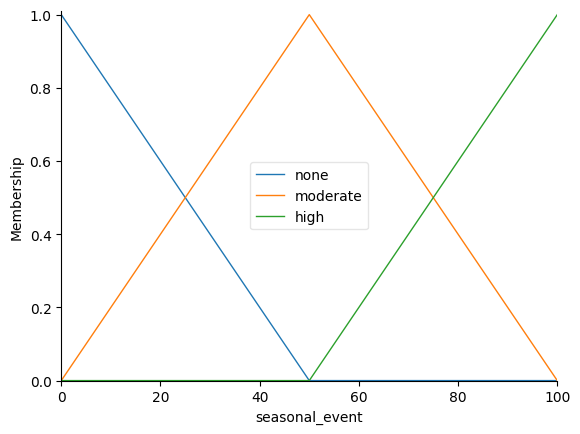

In [18]:
seasonal_event['none'] = fuzz.trimf(seasonal_event.universe, [0, 0, 50])
seasonal_event['moderate'] = fuzz.trimf(seasonal_event.universe, [0,50,100])
seasonal_event['high'] = fuzz.trimf(seasonal_event.universe, [50,100,100])
seasonal_event.view()

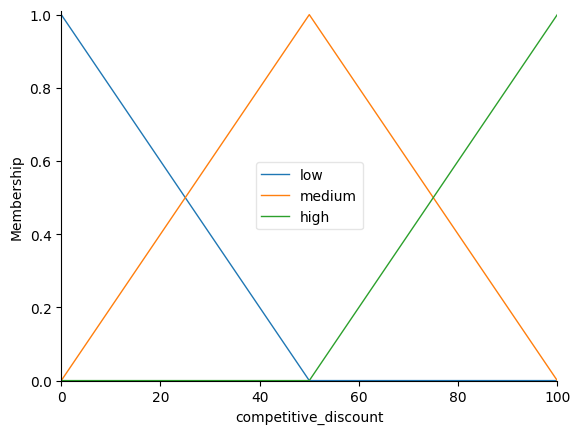

In [19]:
competitive_discount['low'] = fuzz.trimf(competitive_discount.universe, [0, 0, 50])
competitive_discount['medium'] = fuzz.trimf(competitive_discount.universe, [0,50,100])
competitive_discount['high'] = fuzz.trimf(competitive_discount.universe, [50,100,100])
competitive_discount.view()

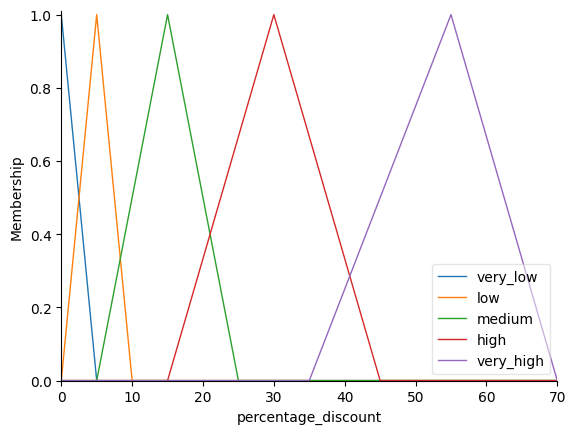

In [39]:
percentage_discount['very_low'] = fuzz.trimf(percentage_discount.universe, [0,0,5])
percentage_discount['low'] = fuzz.trimf(percentage_discount.universe, [0,5,10])
percentage_discount['medium'] = fuzz.trimf(percentage_discount.universe, [5,15,25])
percentage_discount['high'] = fuzz.trimf(percentage_discount.universe, [15,30,45])
percentage_discount['very_high'] = fuzz.trimf(percentage_discount.universe, [35,55,70])
percentage_discount.view()

In [40]:
rule1=ctrl.Rule(store_rating['high'] & sales_volume['high'] & profit_margin['high'],percentage_discount['very_low'])
rule2=ctrl.Rule(store_rating['low'] & sales_volume['low'] & profit_margin['high'],percentage_discount['high'])
rule3=ctrl.Rule(seasonal_event['high'] &competitive_discount['high'],percentage_discount['very_high'])
rule4=ctrl.Rule(store_rating['medium'] & sales_volume['medium'] & profit_margin['medium'],percentage_discount['medium'])
rule5=ctrl.Rule(competitive_discount['low'] & sales_volume['high'] & profit_margin['low'],percentage_discount['very_low'])
rule6=ctrl.Rule(store_rating['low'] & seasonal_event['none'],percentage_discount['medium'])
rule7=ctrl.Rule(sales_volume['low'] & profit_margin['low'],percentage_discount['very_high'])

phần trăm chiết khấu là: 45.45919602857488


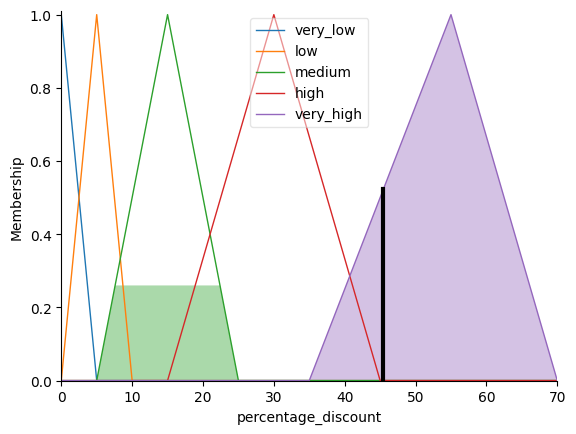

In [50]:
control_system=ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7])
discount_system=ctrl.ControlSystemSimulation(control_system)
discount_system.input['store_rating']=4.3
discount_system.input['sales_volume']=50
discount_system.input['profit_margin']=13
discount_system.input['seasonal_event']=100
discount_system.input['competitive_discount']=100
discount_system.compute()
print('phần trăm chiết khấu là:', discount_system.output['percentage_discount'])
percentage_discount.view(sim=discount_system)